In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
outer_data = np.load('../data/k49-train-imgs.npz')
inner_data_bytes = outer_data[outer_data.files[0]]
with io.BytesIO(inner_data_bytes) as f:
    inner_data = np.load(f)
    X_train = inner_data[inner_data.files[0]]

print(f"Jumlah gambar: {X_train.shape[0]}")
print(f"Ukuran tiap gambar: {X_train.shape[1]}x{X_train.shape[2]} pixel")

Jumlah gambar: 232365
Ukuran tiap gambar: 28x28 pixel


1. **Data Size**: Kita Konfirmasi Kalo ada **232,365** Gamber  dengan $28 \times 28$ pixels.

✅ Berhasil! Jumlah Label: 232365

5 Baris pertama Classmap (Kamus Karakter):
   index codepoint char
0      0    U+3042    あ
1      1    U+3044    い
2      2    U+3046    う
3      3    U+3048    え
4      4    U+304A    お


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28360\2304862933.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classmap['char'], y=counts.values, palette='viridis')


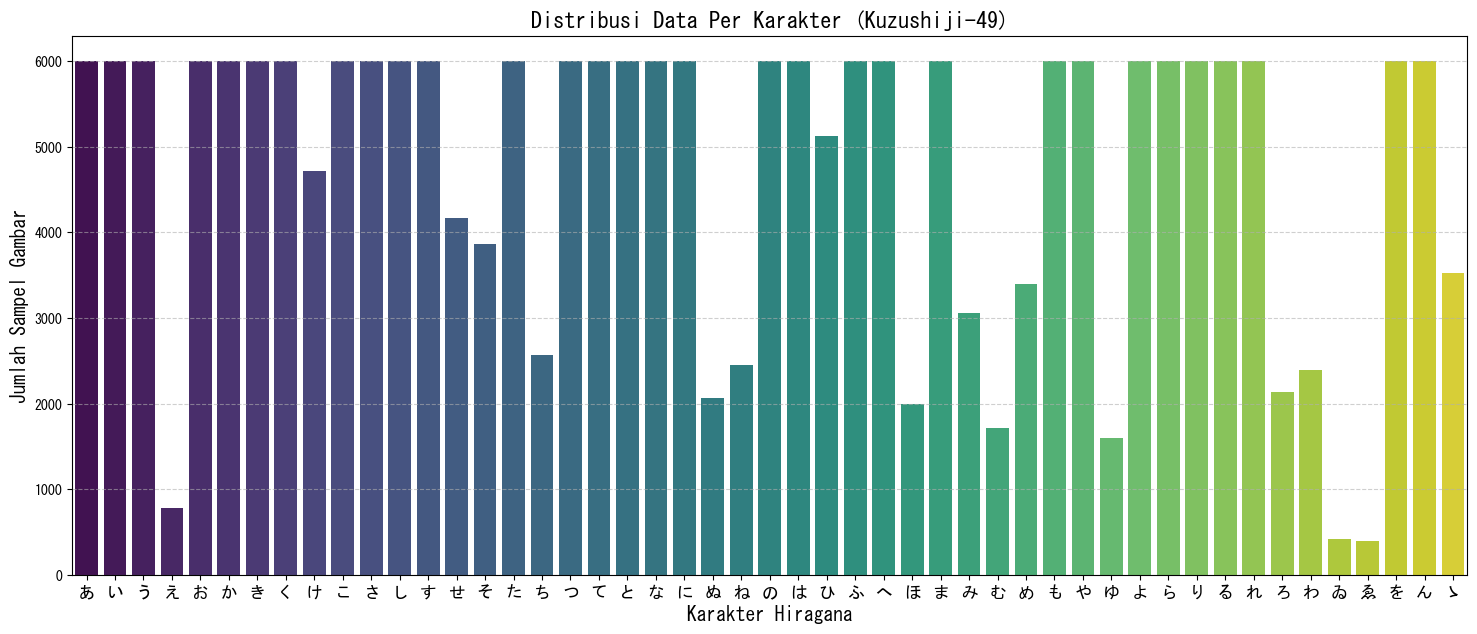

In [ ]:
labels_data = np.load('../data/k49-train-labels.npz')

plt.rcParams['font.family'] = 'MS Gothic' # Font standar Windows untuk Jepang Soal Nya si mat plot gabisa nulis hiragana jadi kita ganti font nya ke MS Gothic yang bisa nulis hiragana dengan baik
y_train = labels_data[labels_data.files[0]] 

classmap = pd.read_csv('../data/k49_classmap.csv')

print(f"Jumlah Label: {len(y_train)}")
print("\n5 Baris pertama Classmap (Kamus Karakter):")
print(classmap.head())

# --- 3. PROSES DISTRIBUSI KELAS (EDA 3.1) ---

# Menghitung jumlah sampel per karakter
counts = pd.Series(y_train).value_counts().sort_index()

# Menyesuaikan ukuran figure agar Hiragana tidak berdempetan
plt.figure(figsize=(18, 7)) 

# Menggunakan kolom 'char' dari classmap sebagai label sumbu X
sns.barplot(x=classmap['char'], y=counts.values, palette='viridis')

# Memberikan Judul dan Label yang Jelas
plt.title('Distribusi Data Per Karakter (Kuzushiji-49)', fontsize=16)
plt.xlabel('Karakter Hiragana', fontsize=14)
plt.ylabel('Jumlah Sampel Gambar', fontsize=14)

# PENTING: Menampilkan karakter Hiragana agar tetap tegak dan terlihat jelas
plt.xticks(rotation=0, fontsize=12) 
# Menambahkan grid bantu agar tinggi batang mudah dibaca
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

2. **Data imbalance**: Disini Ada **18** karakter Hiragana Yang Berada Di bawah 6000 
Karakter seperti ゑ (we) dan ゐ (wi) memiliki sampel di bawah 1,000
Disini Menunjukan Bahwa ada Data Imbalance yang sangat signifikan

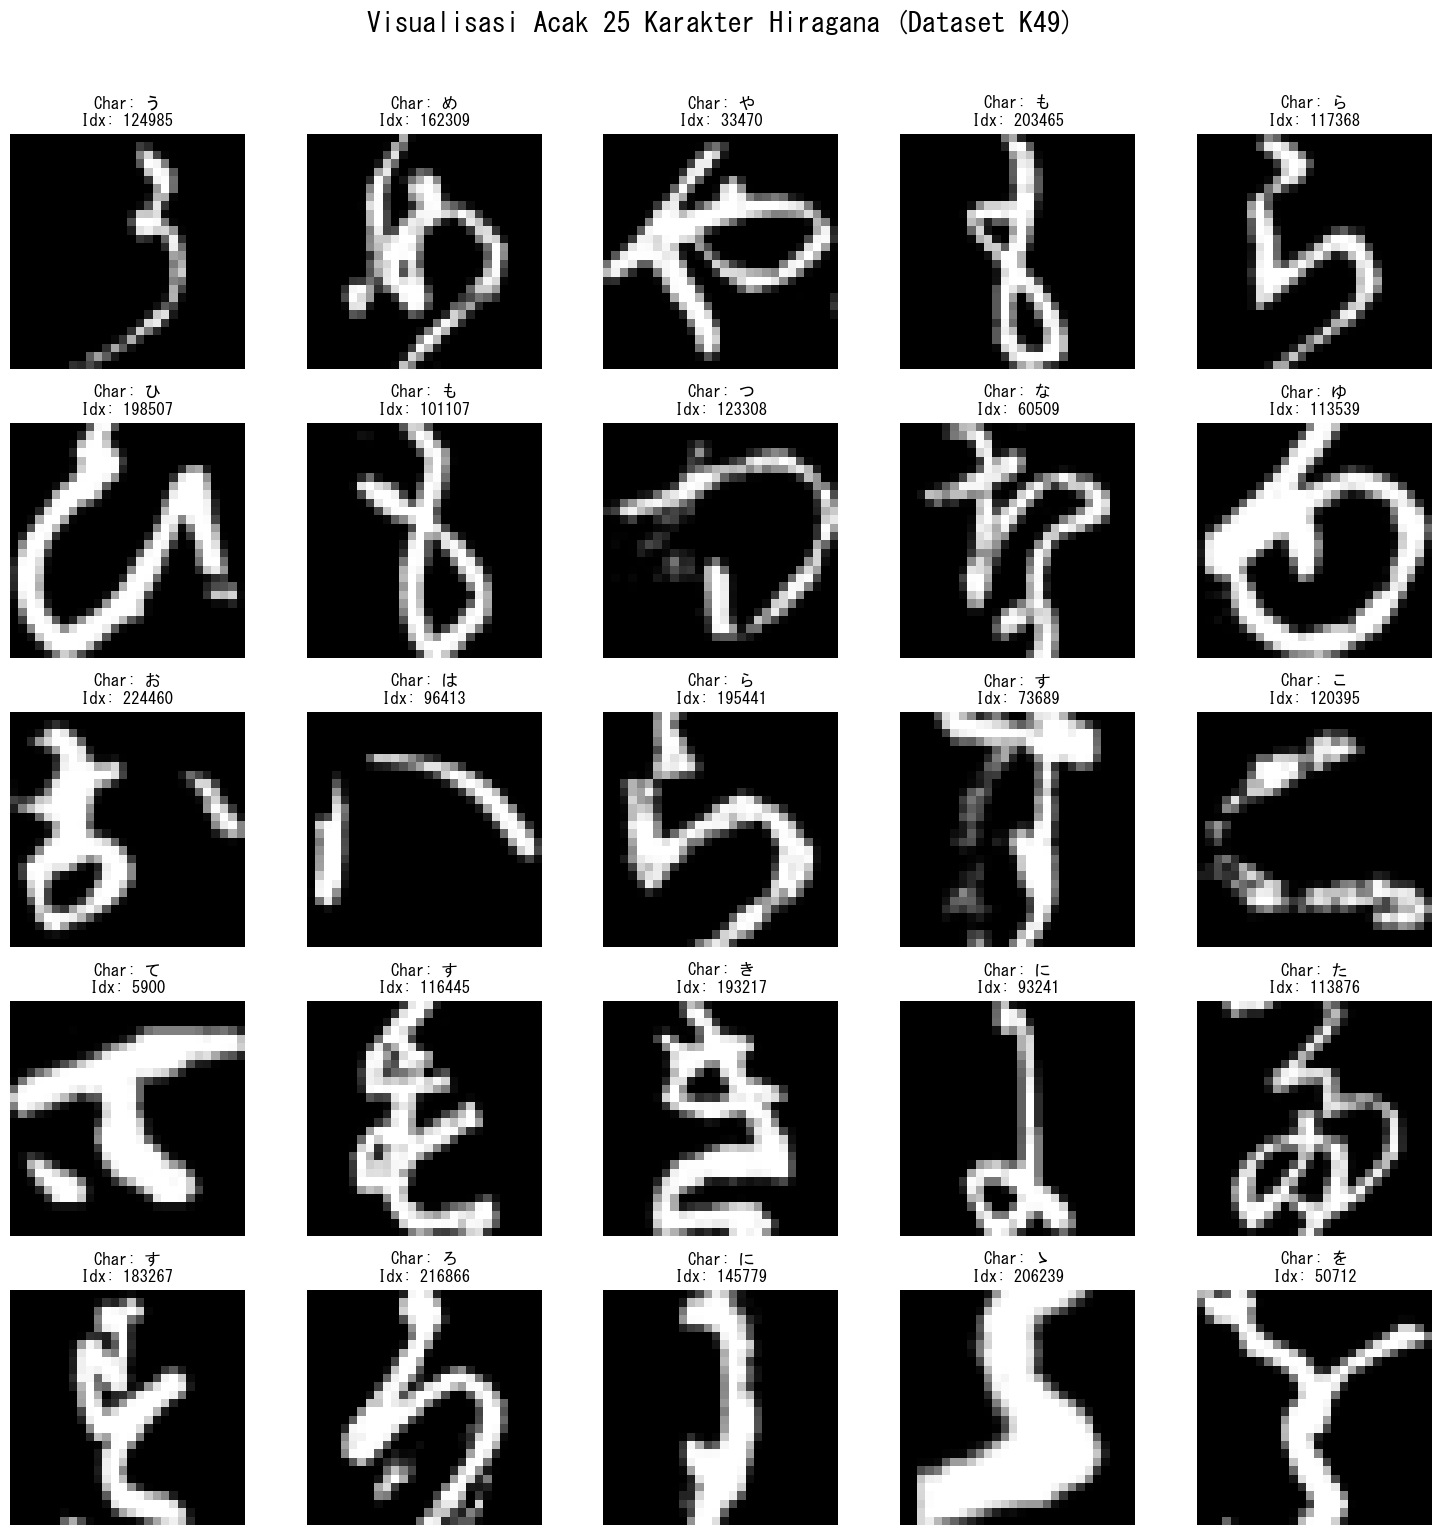

In [13]:
# 1. Mengambil 25 index secara acak dari total data X_train
# len(X_train) memastikan kita mengambil dari rentang data yang benar (232.365)
random_indices = np.random.randint(0, len(X_train), size=25)

# 2. Mengatur ukuran figure (grid 5x5)
plt.figure(figsize=(15, 15))

for i, idx in enumerate(random_indices):
    plt.subplot(5, 5, i+1)
    
    # Menampilkan gambar grayscale
    plt.imshow(X_train[idx], cmap='gray')
    
    # Mengambil nama karakter dari classmap berdasarkan label di y_train
    char_name = classmap.iloc[y_train[idx]]['char']
    
    # Memberikan judul tiap gambar: Nama Karakter dan Index aslinya
    plt.title(f"Char: {char_name}\nIdx: {idx}", fontsize=12)
    plt.axis('off') # Menghilangkan sumbu x-y agar rapi

plt.suptitle("Visualisasi Acak 25 Karakter Hiragana (Dataset K49)", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

3. **Visual Quality**: Kita disini udah Ngacak 25 karkater buat ngecek apa ada nois dan jawaban nya adalah ,iya ada beberapa seperti bercak bercak pada karakter nya

4. **Action Plan**: 
   - Use **Normalization** to handle pixel intensity variations.
   - Consider **Class Weighting** in SVM to handle the imbalance.
   - Apply **HOG Feature Extraction** to focus on the shape rather than individual pixels.

Nilai piksel minimum: 0.0
Nilai piksel maksimum: 1.0


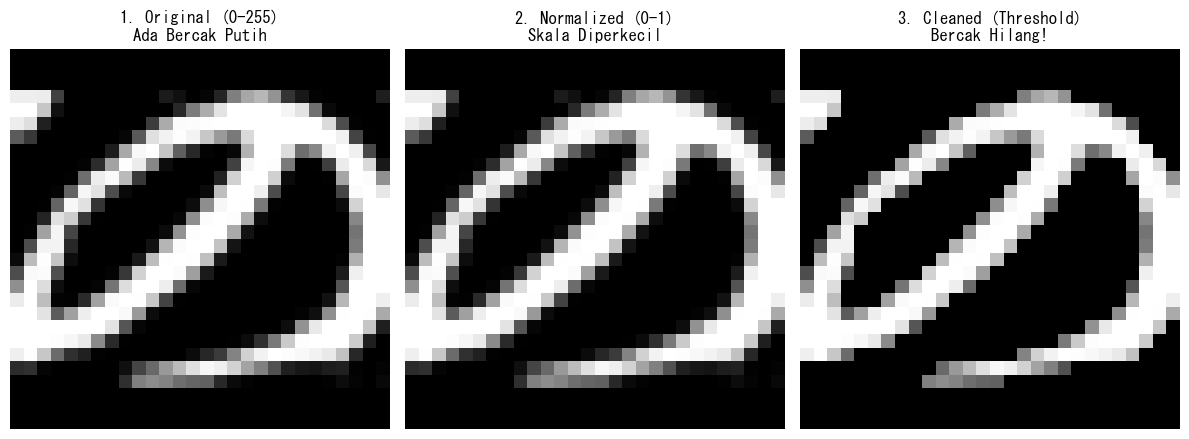

In [15]:
# Mengubah tipe data menjadi float dan menormalisasi (0-1)
X_train_normalized = X_train.astype('float32') / 255.0

print(f"Nilai piksel minimum: {X_train_normalized.min()}")
print(f"Nilai piksel maksimum: {X_train_normalized.max()}")


# 1. Pilih satu index gambar yang kamu lihat ada bercaknya (misal index ke-10)
sample_idx = 10 

# 2. Proses Pembersihan
# Step A: Normalisasi (0-1)
img_normalized = X_train[sample_idx].astype('float32') / 255.0

# Step B: Thresholding (Menghapus bercak halus)
# Kita anggap semua piksel di bawah 0.3 sebagai "sampah/noise" dan diubah jadi 0 (hitam)
img_cleaned = np.where(img_normalized < 0.3, 0, img_normalized)

# 3. Tampilkan Perbandingan
plt.figure(figsize=(12, 5))

# Gambar Asli
plt.subplot(1, 3, 1)
plt.imshow(X_train[sample_idx], cmap='gray')
plt.title(f"1. Original (0-255)\nAda Bercak Putih")
plt.axis('off')

# Gambar Setelah Normalisasi
plt.subplot(1, 3, 2)
plt.imshow(img_normalized, cmap='gray')
plt.title(f"2. Normalized (0-1)\nSkala Diperkecil")
plt.axis('off')

# Gambar Setelah Thresholding
plt.subplot(1, 3, 3)
plt.imshow(img_cleaned, cmap='gray')
plt.title(f"3. Cleaned (Threshold)\nBercak Hilang!")
plt.axis('off')

plt.tight_layout()
plt.show()

## Disini Kita Melakukan Proses Normalisasi  untuk Mengubah Skala nya dari 0-255 jadi 0.0-1.0 ##
Kemudian Melakukan Thresholding Buat Hapus Noise nya(Bercak Putih)

In [18]:
# 1. Normalisasi: Ubah skala 0-255 jadi 0.0-1.0
X_train_norm = X_train.astype('float32') / 255.0
X_train_clean = np.where(X_train_norm < 0.3, 0, X_train_norm)

print("✅ Seluruh data sudah dibersihkan!")

✅ Seluruh data sudah dibersihkan!


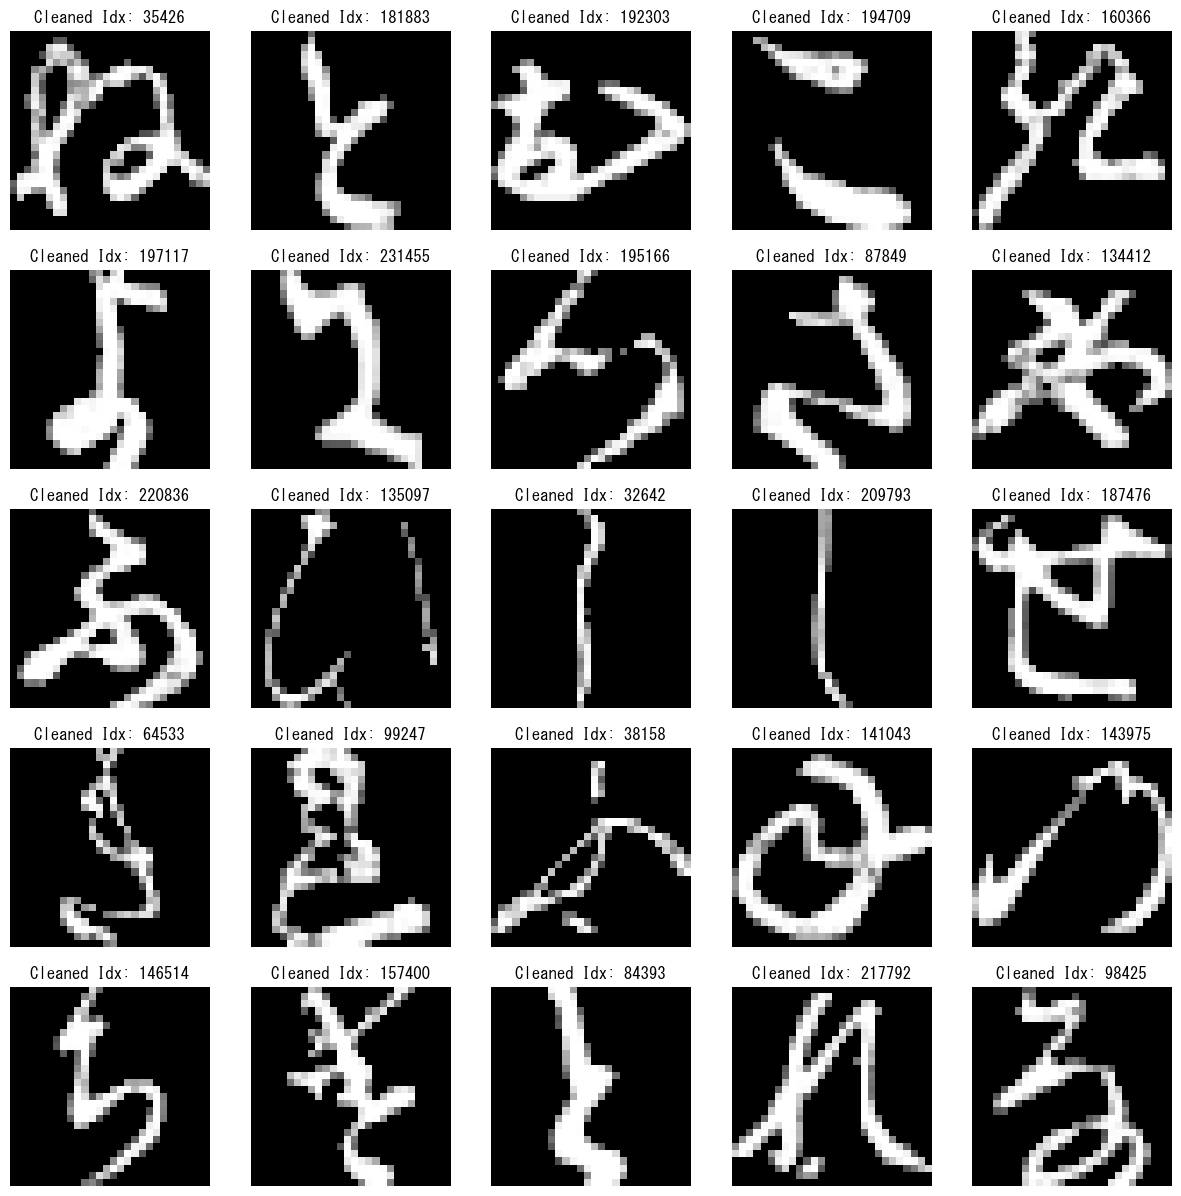

In [19]:
# Cek hasil pembersihan pada 25 gambar yang sama
plt.figure(figsize=(15, 15))
for i, idx in enumerate(random_indices):
    plt.subplot(5, 5, i+1)
    
    # PAKAI X_train_clean SEKARANG
    plt.imshow(X_train_clean[idx], cmap='gray') 
    
    plt.title(f"Cleaned Idx: {idx}")
    plt.axis('off')
plt.show()

In [20]:
X_train_norm = X_train.astype('float32') / 255.0
X_train_preprocessed = np.where(X_train_norm < 0.3, 0, X_train_norm)
print(f"Normalisasi Selesai")
print(f"Rentang nilai sekarang: {X_train_preprocessed.min()} sampai {X_train_preprocessed.max()}")

Normalisasi Selesai
Rentang nilai sekarang: 0.0 sampai 1.0


## HOG Exctraction


In [ ]:
from skimage.feature import hog
import numpy as np

# List untuk menampung fitur hasil HOG
hog_features = []

print("⏳ Sedang mengekstraksi fitur HOG ")

# Kita lakukan looping untuk semua gambar yang sudah bersih (X_train_preprocessed)
for img in X_train_preprocessed:
    # fd adalah 'feature descriptor' (hasil HOG)
    fd = hog(img, orientations=9, pixels_per_cell=(4, 4), 
             cells_per_block=(2, 2), visualize=False)
    hog_features.append(fd)

# Ubah menjadi array numpy agar bisa dibaca SVM
X_train_hog = np.array(hog_features)

print(f"✅Selesai! Bentuk data HOG sekarang: {X_train_hog.shape}")

⏳ Sedang mengekstraksi fitur HOG (Sabar ya, Will...)...
✅Selesai! Bentuk data HOG sekarang: (232365, 1296)


## Class Weighting buart ngehadepin data imbalance 

In [26]:
from sklearn.utils import class_weight
import numpy as np

# 1. Hitung bobot otomatis (Balanced)
# Ini akan memberikan nilai tinggi untuk kelas yang datanya sedikit (rare)
# dan nilai rendah untuk kelas yang datanya melimpah (common)
weights = class_weight.compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

# 2. Simpan dalam bentuk dictionary (Kamus Bobot)
# Dictionary ini yang akan dimasukkan ke parameter SVM nanti
class_weights_dict = dict(enumerate(weights))

# 3. Mari kita cek perbandingannya
# Ambil contoh karakter 'we' (langka) dan 'a' (umum)
print("⚖️ Hasil Perhitungan Class Weights:")
print(f"Total Kelas: {len(class_weights_dict)}")
print(f"Bobot Karakter Langka (Index 3): {class_weights_dict[3]:.4f}")
print(f"Bobot Karakter Umum (Index 0): {class_weights_dict[0]:.4f}")

⚖️ Hasil Perhitungan Class Weights:
Total Kelas: 49
Bobot Karakter Langka (Index 3): 6.1031
Bobot Karakter Umum (Index 0): 0.7904


## Train Data Nya Beneran Udah Pintar Atau Belum 


In [27]:
from sklearn.model_selection import train_test_split

# Kita bagi 80% untuk latihan (Train) dan 20% untuk ujian (Validation)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_hog, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"✅ Data Siap!")
print(f"Jumlah untuk Latihan : {X_train_final.shape[0]} gambar")
print(f"Jumlah untuk Ujian   : {X_val.shape[0]} gambar")

✅ Data Siap!
Jumlah untuk Latihan : 185892 gambar
Jumlah untuk Ujian   : 46473 gambar
